Processing ds-v0/03-finished-yolo/train/images/01-synthetic_synthetic_00439_right_aug_1.jpg
Processing ds-v0/03-finished-yolo/train/images/01-synthetic_synthetic_00083_left_aug_2.jpg
Processing ds-v0/03-finished-yolo/train/images/920883527_left.jpg
Processing ds-v0/03-finished-yolo/train/images/01-synthetic_synthetic_00461_left_aug_3.jpg
Processing ds-v0/03-finished-yolo/train/images/920863025_right_aug_2.jpg
Processing ds-v0/03-finished-yolo/train/images/920693018_right_aug_0.jpg
Processing ds-v0/03-finished-yolo/train/images/01-synthetic_synthetic_00289_left_aug_0.jpg
Processing ds-v0/03-finished-yolo/train/images/919997219_left_aug_1.jpg
Processing ds-v0/03-finished-yolo/train/images/920630179_left_aug_1.jpg
Processing ds-v0/03-finished-yolo/train/images/920696751_left_aug_3.jpg
Processing ds-v0/03-finished-yolo/train/images/919949882_left_aug_1.jpg
Processing ds-v0/03-finished-yolo/train/images/921493564_right_aug_3.jpg
Processing ds-v0/03-finished-yolo/train/images/921441894_left_

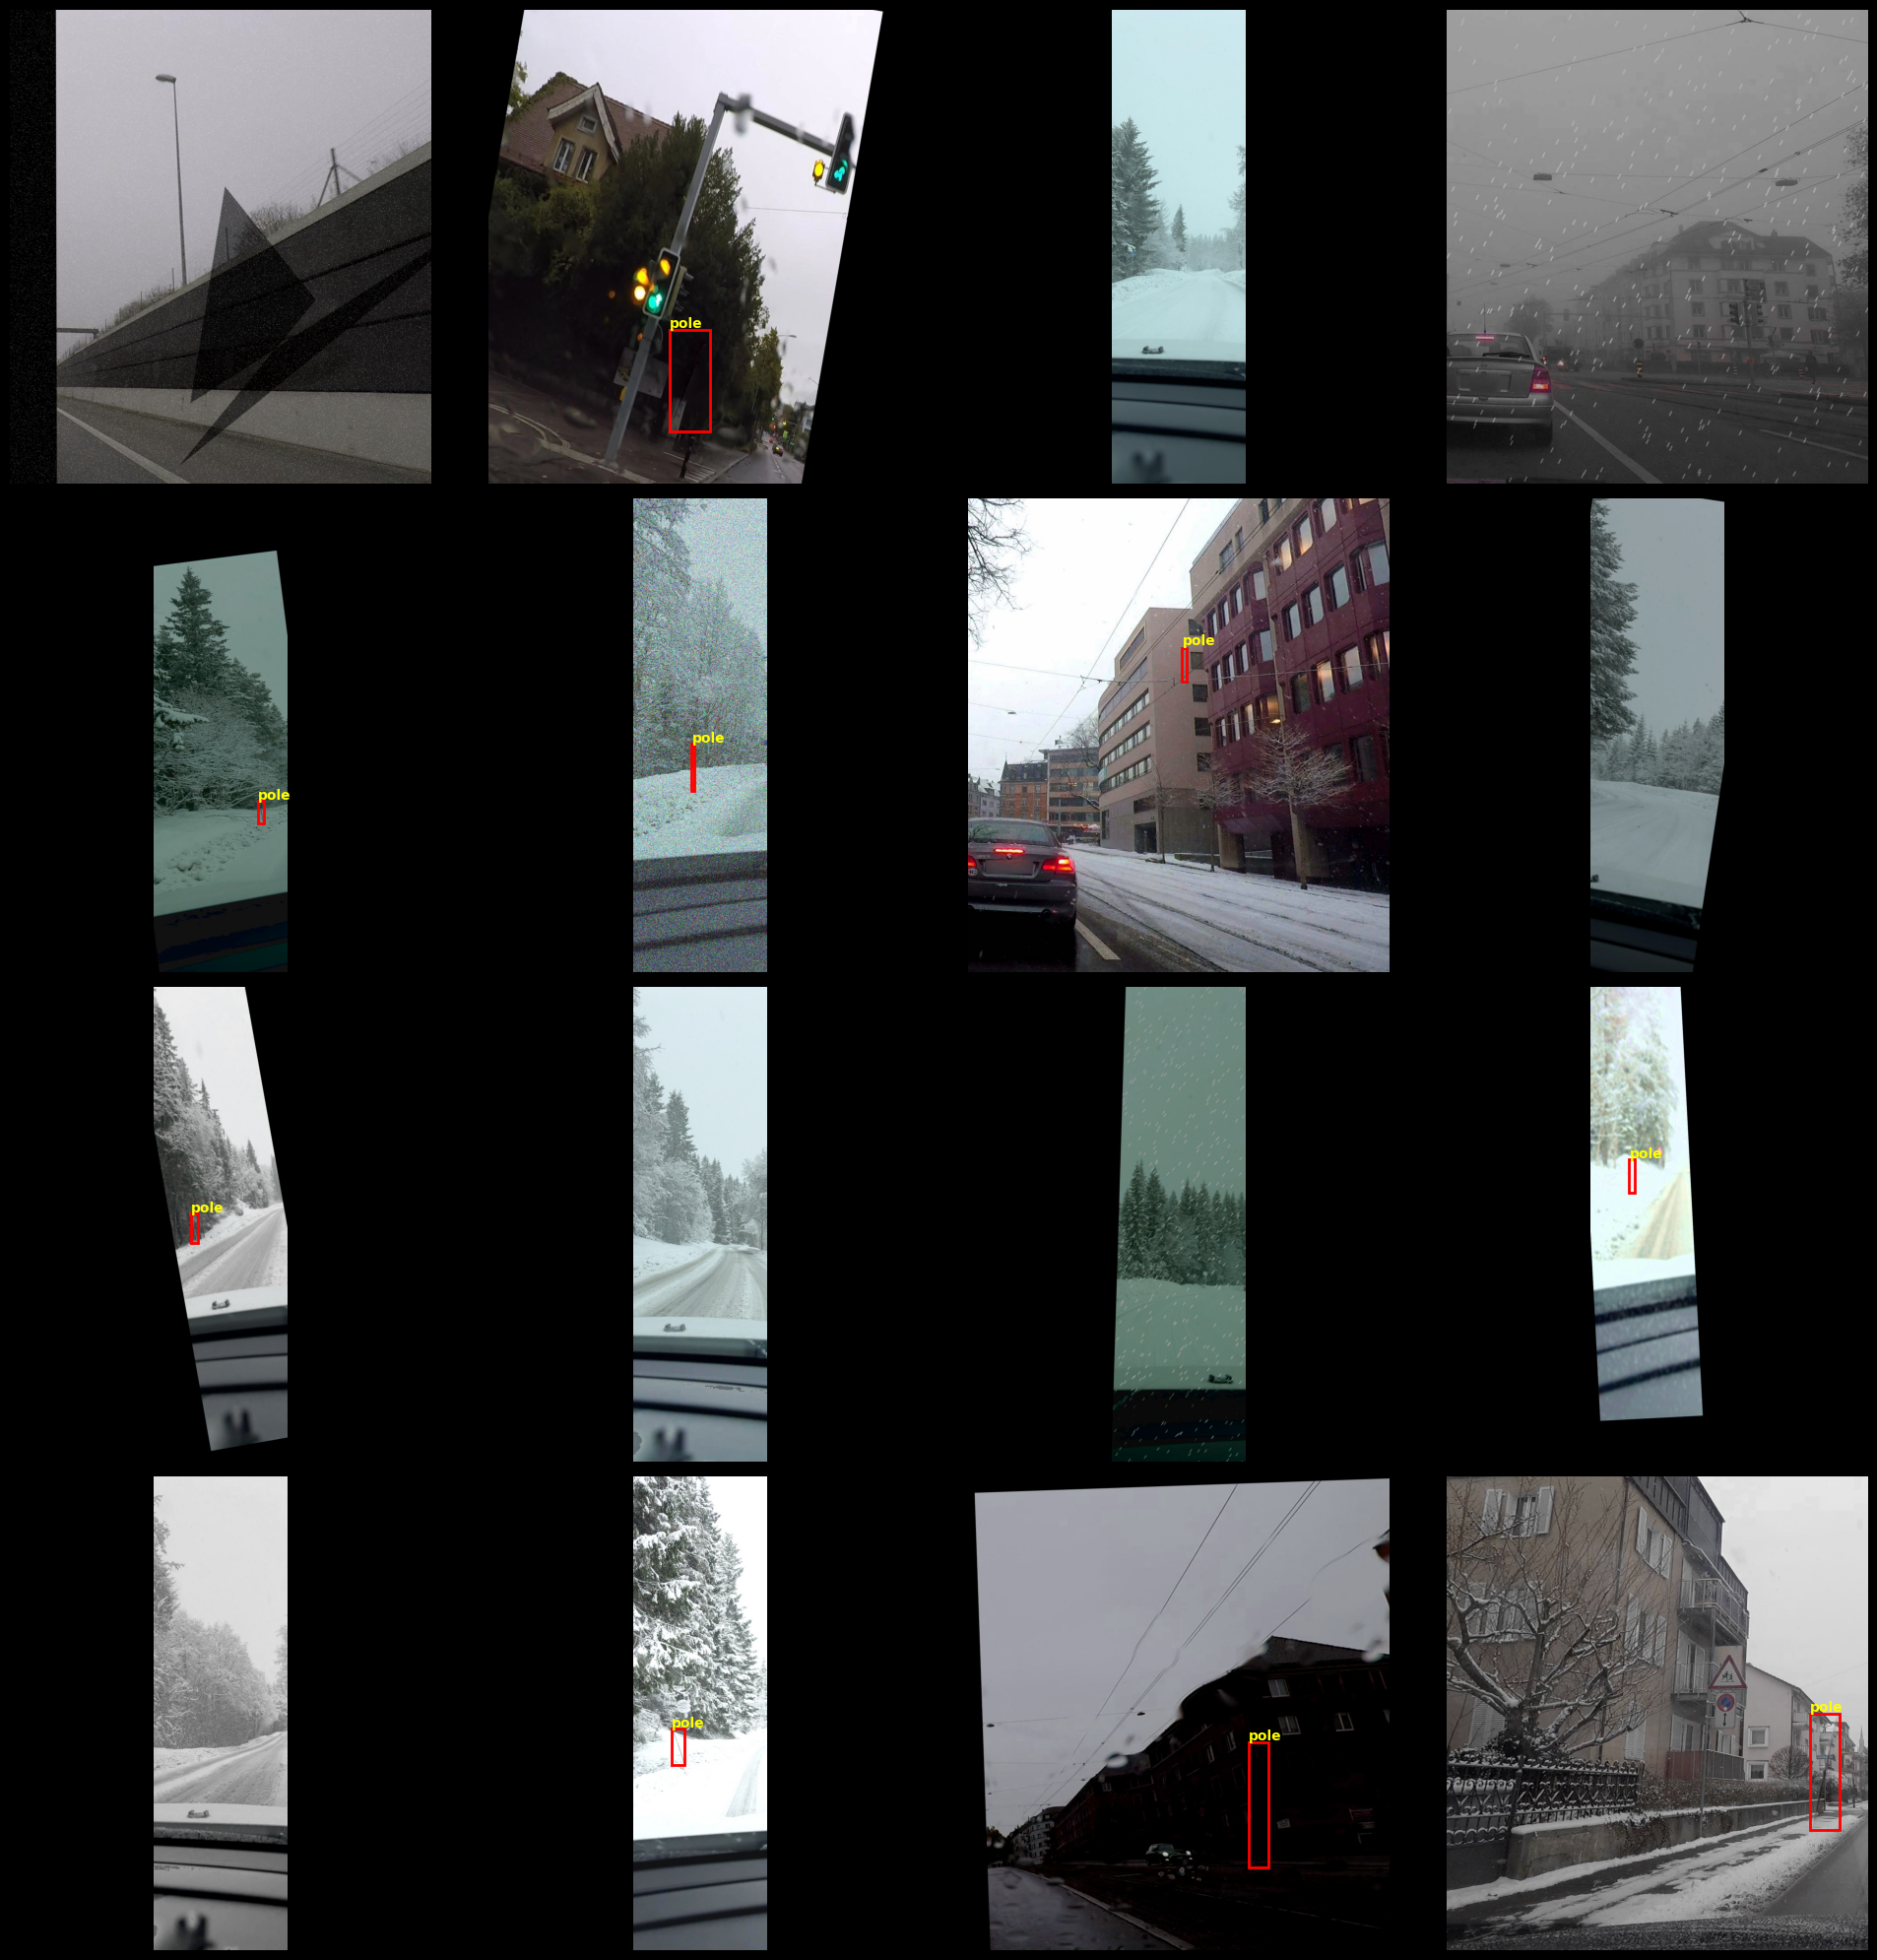

In [6]:
from pathlib import Path
import random
import matplotlib.patches as patches
import cv2
from matplotlib import pyplot as plt

from snowpole_detector.ds_split_images import yolo_to_xyxy, YoloBbox
from snowpole_detector.settings import get_settings
settings = get_settings()

src = settings.DATASET_FINISHED_YOLO

img_dir = src / "train/images"
label_dir = src / "train/labels"
# --- Class mapping (adjust as needed) ---
label_map = {
    0: "pole",
}
# --- Collect images ---
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
images = [
    f for f in img_dir.iterdir()
    if f.suffix.lower() in valid_extensions
]
images = random.sample(images, 16)


# --- Plot 5x5 grid ---
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()


for ax, img_file in zip(axes, images):
    img = cv2.imread(str(img_file))
    if img is None:
        print(f"Could not read {img_file}")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')
    print(f"Processing {img_file}")

    lbl_file = label_dir / f"{img_file.stem}.txt"
    if lbl_file.exists():
        with open(lbl_file, "r") as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                class_id, x_c, y_c, w, h = map(float, parts)
                xyxy = yolo_to_xyxy(
                    YoloBbox(class_id=int(class_id), x_center=x_c, y_center=y_c, width=w, height=h), img.shape)
                rect = patches.Rectangle(
                    (xyxy["xmin"], xyxy["ymin"]),
                    xyxy["xmax"] - xyxy["xmin"],
                    xyxy["ymax"] - xyxy["ymin"],
                    linewidth=2,
                    edgecolor='red',
                    facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(
                    xyxy["xmin"], xyxy["ymin"] - 5,
                    label_map.get(int(class_id), str(int(class_id))),
                    color='yellow',
                    fontsize=10,
                    weight='bold'
                )

plt.tight_layout()
plt.show()